fatal: destination path 'aprendizaje_profundo' already exists and is not an empty directory.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,883 (11.26 KB)

 Trainable params: 2,883 (11.26 KB)

 Non-trainable params: 0 (0.00 B)

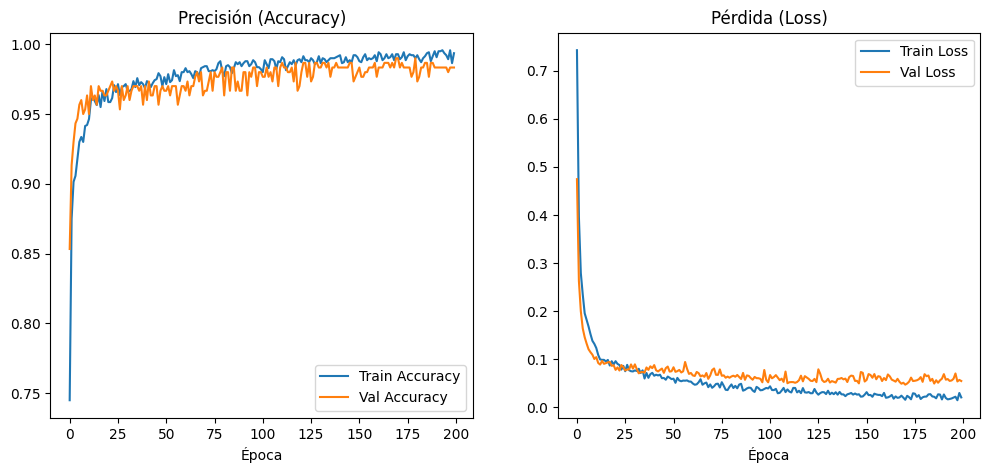

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Total Params:     2883
Train Accuracy:   0.9964
Val Accuracy:     0.9833
Test Accuracy:    0.9700
F1 Macro (Test):  0.9323


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

!git clone https://github.com/macaspe4/aprendizaje_profundo.git

sys.path.append('/content/aprendizaje_profundo')

from modelos.modelo_complejos2 import crear_modelo

df = pd.read_csv('wfh_burnout_dataset.csv')
features = ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken',
            'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion',
            'isolation_index', 'fatigue_score']
X = df[features]
y = LabelEncoder().fit_transform(df['burnout_risk'])

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

model = crear_modelo(X_train_sc.shape[1])
model.summary()

history = model.fit(X_train_sc, y_train,
                    validation_data=(X_val_sc, y_val),
                    epochs=200,
                    verbose=0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Precisión (Accuracy)')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.legend()

plt.show()

y_train_pred = np.argmax(model.predict(X_train_sc), axis=1)
y_val_pred = np.argmax(model.predict(X_val_sc), axis=1)
y_test_pred = np.argmax(model.predict(X_test_sc), axis=1)


print(f"Total Params:     {model.count_params()}")
print(f"Train Accuracy:   {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Val Accuracy:     {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Test Accuracy:    {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1 Macro (Test):  {f1_score(y_test, y_test_pred, average='macro'):.4f}")


### Conclusión
Este segundo modelo es más potente, con 2.883 parámetros, y además incluye una capa de Dropout (0.2) para que el aprendizaje sea más estable y evitar que el modelo memorice los datos. Se entrenó durante 200 épocas, alcanzando una precisión muy alta: 99,64% en entrenamiento, 98,33% en validación y 97,00% en test.
Como estos resultados son bastante parecidos entre sí, indica que el modelo aprende bien y generaliza correctamente, sin sobreajustar demasiado. Además, el F1 Macro de 0,9323 muestra que el modelo clasifica de forma equilibrada las tres categorías de riesgo de burnout (bajo, medio y alto). En resumen, aumentar las épocas de entrenamiento y usar Dropout ha permitido obtener un modelo muy preciso y fiable incluso con datos nuevos